# 🎉 Welcome to the ' SheCures: AI for Diabetes Prediction – Celebrating International Girls in ICT Day' Hackathon Starter Notebook
This notebook will help you get started on your journey to building an AI model for predicting diabetes types in African women.
**Organized by Dare to be Women Tech** in celebration of *International Girls in ICT Day*.

## 🧩 Problem Statement
Your task is to build a machine learning model that can classify the type of diabetes (e.g., Type 2 or gestational) in women based on health-related features.

In [3]:
#!pip install -U scikit-learn
#import sklearn
#print(sklearn.__version__)
#!pip install xgboost

In [4]:
# 📦 Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder 
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [5]:
# 📂 Load the dataset (update the path as needed)
df = pd.read_csv("Train.csv")
df.head()

,Genetic Markers,Family History,Insulin Levels,Blood Glucose Levels,Glucose Tolerance Test,BMI,Waist Circumference,Physical Activity,Dietary Habits,Smoking Status,...,Blood Pressure,Cholesterol Levels,Liver Function Tests,Previous Gestational Diabetes,Pregnancy History,Weight Gain During Pregnancy,Ethnicity,Socioeconomic Factors,Target,ID
0,Negative,No,33,147,Abnormal,29,34,Moderate,Healthy,Non-Smoker,...,125,207,Normal,No,Complications,28,Low Risk,Low,Type 2 Diabetes,ID_0000ff
1,Negative,Yes,20,118,Normal,24,35,High,Unhealthy,Non-Smoker,...,121,210,Normal,Yes,Complications,15,High Risk,Medium,Prediabetic,ID_000372
2,Negative,Yes,14,142,Abnormal,22,30,Low,Healthy,Non-Smoker,...,90,167,Normal,Yes,Complications,13,Low Risk,Low,Type 1 Diabetes,ID_0005b8
3,Negative,Yes,38,141,Abnormal,27,34,High,Healthy,Smoker,...,119,219,Normal,No,Normal,25,Low Risk,High,Type 2 Diabetes,ID_000f18
4,Positive,Yes,20,120,Abnormal,24,36,Low,Unhealthy,Smoker,...,120,223,Normal,Yes,Complications,10,Low Risk,Medium,Gestational Diabetes,ID_0011f6


In [6]:
# ℹ️ Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15094 entries, 0 to 15093
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Genetic Markers                15094 non-null  object
 1   Family History                 15094 non-null  object
 2   Insulin Levels                 15094 non-null  int64 
 3   Blood Glucose Levels           15094 non-null  int64 
 4   Glucose Tolerance Test         15094 non-null  object
 5   BMI                            15094 non-null  int64 
 6   Waist Circumference            15094 non-null  int64 
 7   Physical Activity              15094 non-null  object
 8   Dietary Habits                 15094 non-null  object
 9   Smoking Status                 15094 non-null  object
 10  Alcohol Consumption            15094 non-null  object
 11  Blood Pressure                 15094 non-null  int64 
 12  Cholesterol Levels             15094 non-null  int64 
 13  L

In [7]:
# 📊 Basic statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Insulin Levels,15094.0,20.145952,9.633169,5.0,13.0,18.0,25.0,49.0
Blood Glucose Levels,15094.0,128.760302,25.548681,90.0,110.0,122.0,141.0,199.0
BMI,15094.0,26.078309,5.607679,15.0,22.0,26.0,30.0,39.0
Waist Circumference,15094.0,35.738174,5.041412,28.0,32.0,35.0,39.0,49.0
Blood Pressure,15094.0,117.043328,12.844156,90.0,109.0,117.0,125.0,149.0
Cholesterol Levels,15094.0,208.352458,34.766744,150.0,182.0,204.0,230.0,299.0
Weight Gain During Pregnancy,15094.0,20.120578,7.616550,5.0,15.0,20.0,25.0,39.0


In [8]:
# 🧮 Class distribution
df["diabetes_type"] = df["Target"]
df['diabetes_type'].value_counts()

diabetes_type
Type 1 Diabetes         3825
Type 2 Diabetes         3795
Prediabetic             3752
Gestational Diabetes    3722
Name: count, dtype: int64

<Axes: >

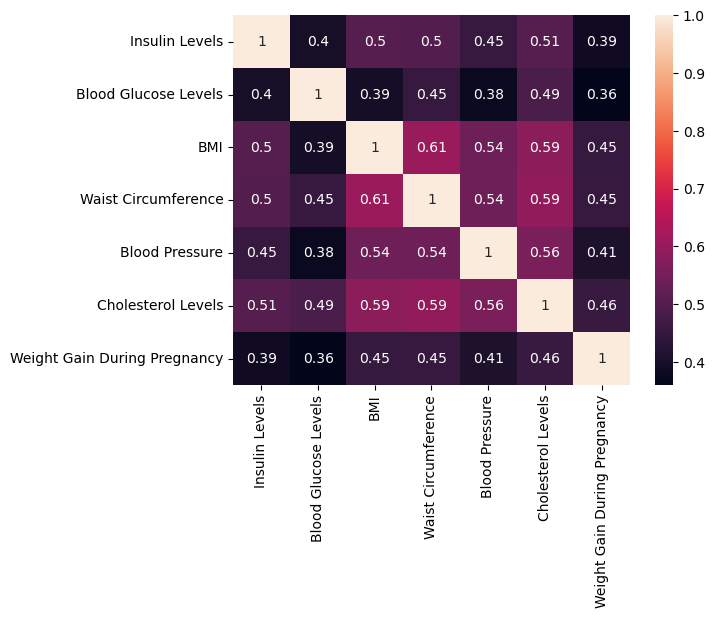

In [9]:
# 🔍 Correlation heatmap
sns.heatmap(df.corr(numeric_only = True),annot = True)

<Axes: >

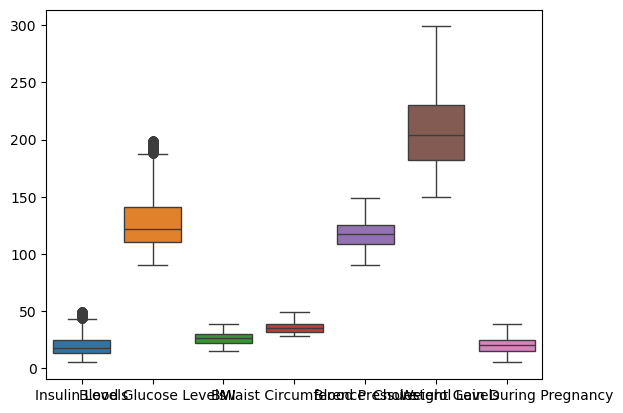

In [10]:
#boxplot
sns.boxplot(df)

In [11]:
#Traitement des valeurs aberrantes
def treat_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.where(df[column] < lower_bound, lower_bound, np.where(df[column] > upper_bound, upper_bound, df[column]))
    return df


In [12]:
df = treat_outliers_iqr(df, 'Insulin Levels')
df = treat_outliers_iqr(df, 'Blood Glucose Levels')

<Axes: >

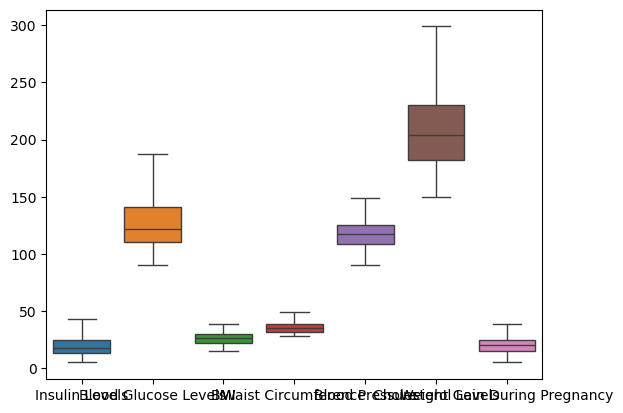

In [13]:
#boxplot
sns.boxplot(df)

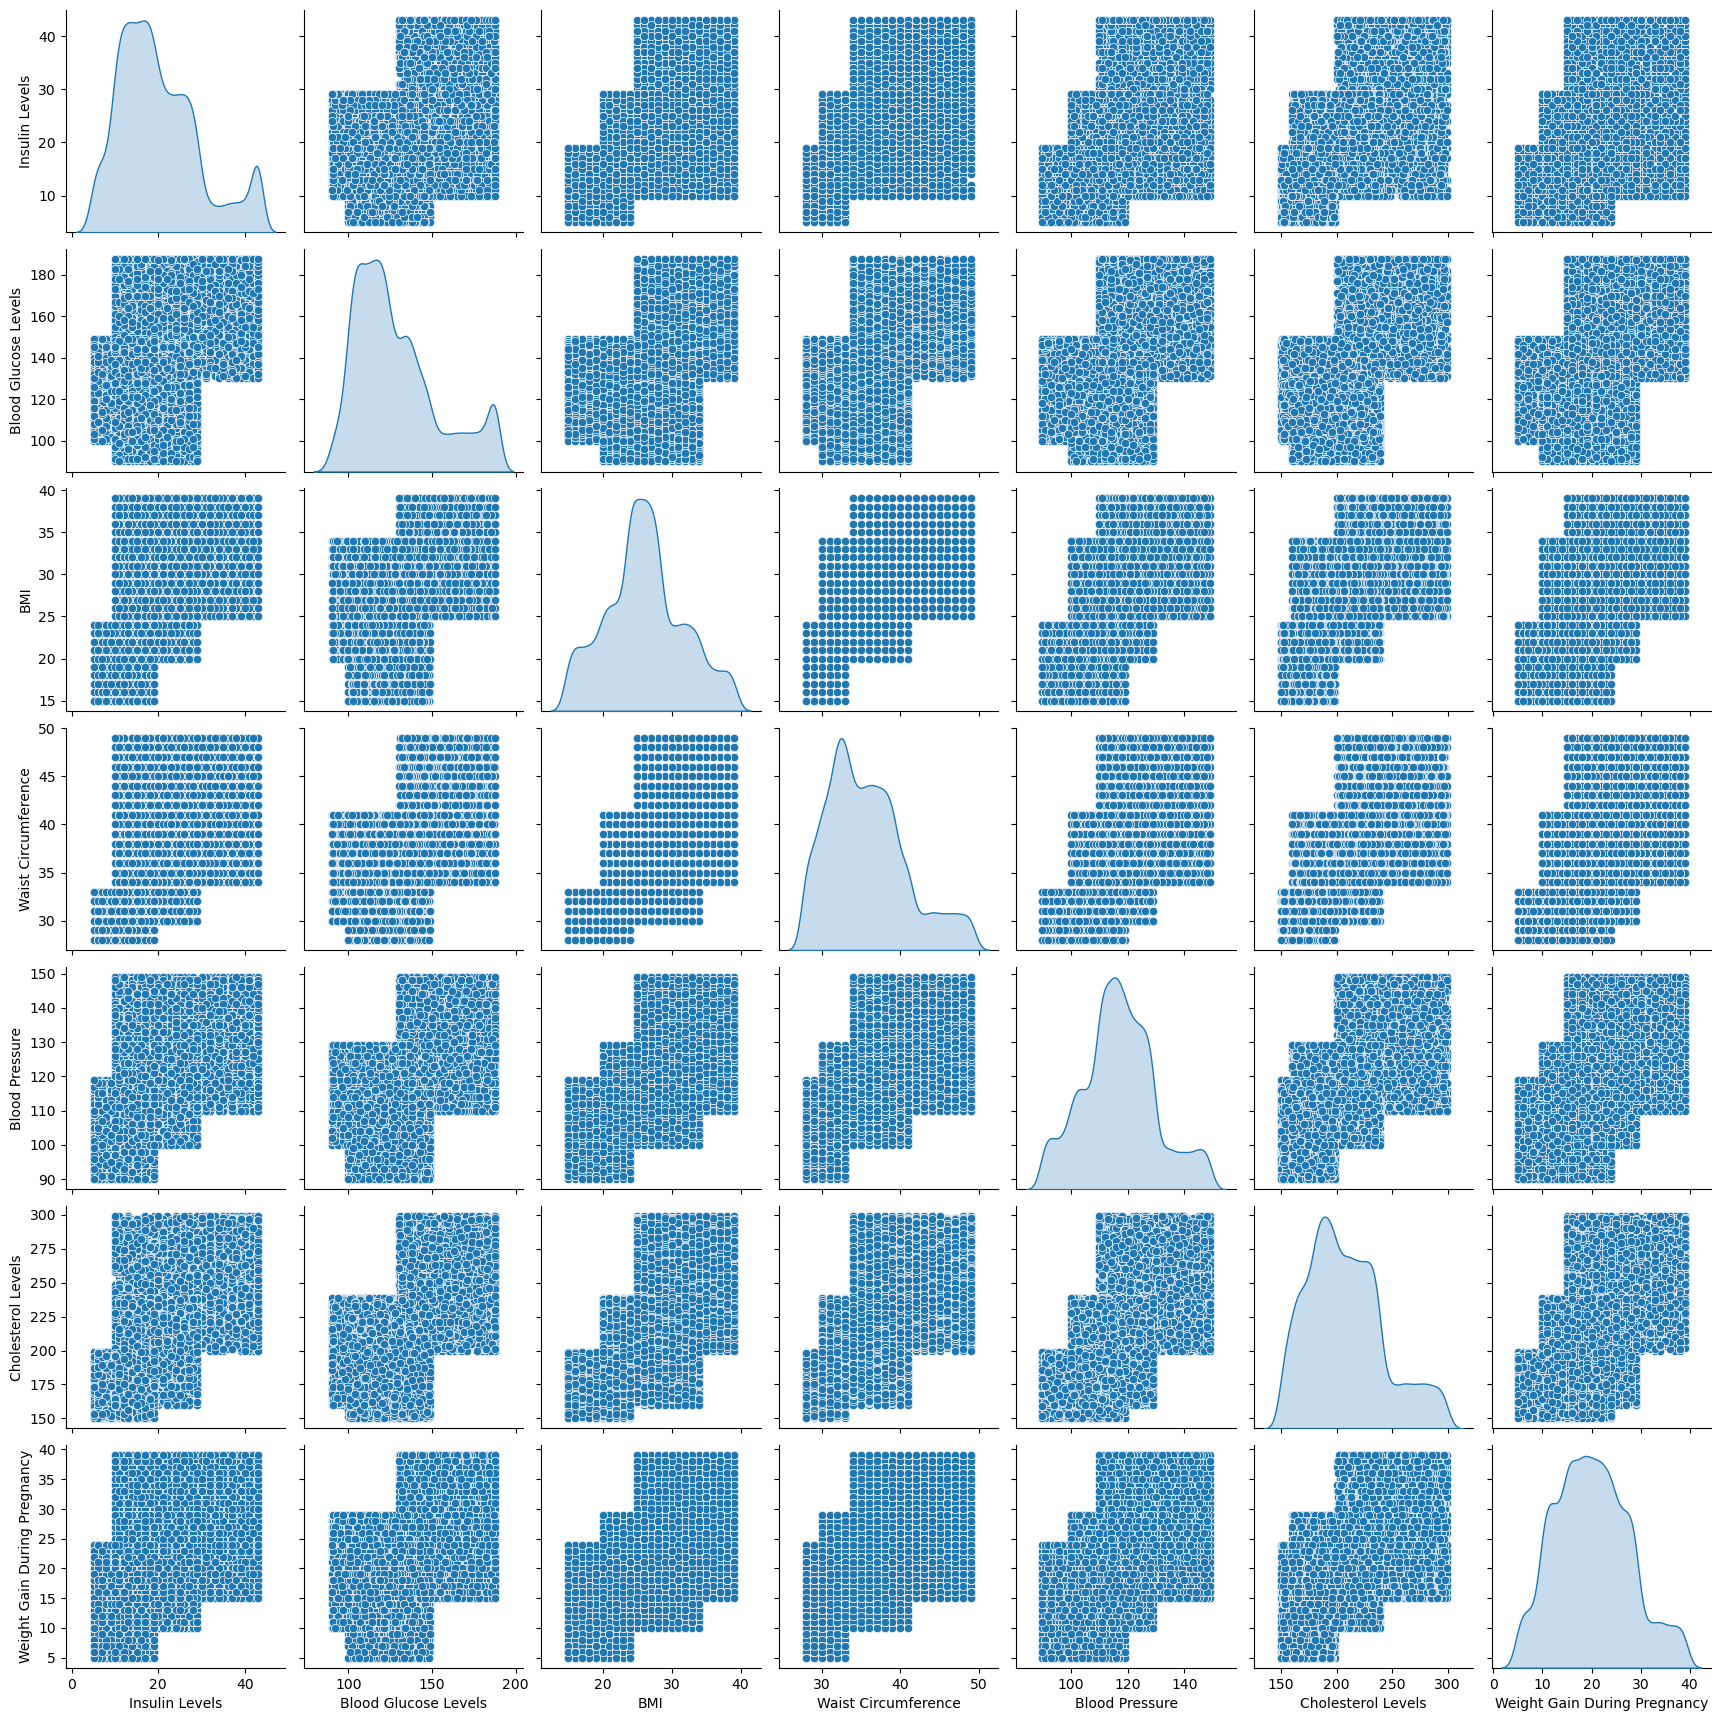

In [14]:
#pairplot of numérical features
sns.pairplot(df, diag_kind="kde")

In [15]:
# 🎯 Data preprocessing
X = df.drop(['diabetes_type', 'Target', 'ID'], axis=1)
y = df['diabetes_type']
num_features = [col for col in X.columns if X[col].dtype != "object"]
cat_features = ['Genetic Markers', 'Family History', 'Glucose Tolerance Test', 'Physical Activity', 'Dietary Habits', 'Smoking Status', 'Alcohol Consumption', 'Liver Function Tests', 'Previous Gestational Diabetes', 'Pregnancy History', 'Ethnicity', 'Socioeconomic Factors']
#num_features = x.select_dtypes(include=['int64', 'float64']).columns.tolist()
#cat_features = x.select_dtypes(include=['object', 'category']).columns.tolist()
#num_features = ["Insulin Levels", "Blood Glucose Levels", "BMI", "Waist Circumference", "Weight Gain During Pregnancy", "Blood Pressure", "Cholesterol Levels",]
#cat_features = ["Genetic Markers", "Family History", "Glucose Tolerance Test", "Physical Activity",	"Dietary Habits", "Smoking Status", "Alcohol Consumption", "Liver Function Tests", "Previous Gestational Diabetes", "Pregnancy History", "Ethnicity", "Socioeconomic Factors"]

num_transformer = Pipeline([
    ("imputer", KNNImputer(n_neighbors = 5)),
    ("scaler", MinMaxScaler())
])

cat_transformer = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown = "ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_transformer, num_features),
    ("cat", cat_transformer, cat_features)
])

In [16]:
# Encode categorical variables and split features/target as needed
df_cleaned = preprocessor.fit_transform(X)
new_columns = (
    num_features +
    list(preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(cat_features))
)

# Convert in Pandas DataFrame
df_cleaned = pd.DataFrame(df_cleaned, columns=new_columns)

# Encode the target variable
labelEncoder = LabelEncoder()
y_encoded = labelEncoder.fit_transform(y)

# Split the preprocessed data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df_cleaned, y_encoded, test_size=0.2, random_state=42)


In [20]:
# 🤖 Baseline prediction Model
svm_model = SVC()
forest_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
tree_model = DecisionTreeClassifier(random_state=42)
reg_model = LogisticRegression(max_iter=200)
gbc_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
xgboost_model =  XGBClassifier(n_estimators=100, max_depth=4, learning_rate=1, objective='binary:logistic')
models =[svm_model, forest_model, tree_model, reg_model, gbc_model, xgboost_model]

In [22]:
def train_model(model,xtrain,ytrain,xtest,ytest):
    print(model)
    model.fit(xtrain,ytrain)
    ypred = model.predict(xtest)
    report = classification_report(ypred, ytest)
    accuracy = accuracy_score(ypred, ytest)
    return ypred, accuracy

In [24]:
# 🤖 Baseline prediction Model
ypred, accuracy1 = train_model(svm_model, X_train,y_train, X_test, y_test)
print("Precision SVM:", accuracy1)

 SVC()
Precision SVM: 0.8347134812851937


In [25]:
# 🤖 Baseline prediction Model

ypred, accuracy2 = train_model(forest_model, X_train,y_train,  X_test, y_test)
print("Précision de Foret:", accuracy2)
#ypred = forest_model.predict(X_test)
#report = classification_report(ypred, y_test_encoded)
#accuracy = accuracy_score(ypred, y_test_encoded)
#print(accuracy)
#choose the best model
#best_model = ...

 RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)
Précision de Foret: 0.9768135144087446


In [26]:
# 🤖 Baseline prediction Model

ypred, accuracy3 = train_model(tree_model, X_train,y_train,  X_test, y_test)
print("Précision de Tree Decision:", accuracy3)
#ypred = forest_model.predict(X_test)
#report = classification_report(ypred, y_test_encoded)
#accuracy = accuracy_score(ypred, y_test_encoded)
#print(accuracy)
#choose the best model
#best_model = ...

 DecisionTreeClassifier(random_state=42)
Précision de Tree Decision: 0.9582643259357403


In [31]:
# 🤖 Baseline prediction Model

ypred, accuracy4 = train_model(reg_model, X_train,y_train,  X_test, y_test)
print("Précision de RGRESSION:", accuracy4)

 LogisticRegression(max_iter=200)
Précision de RGRESSION: 0.8370321298443193


In [30]:
# 🤖 Baseline prediction Model
ypred, accuracyBoost = train_model(gbc_model, X_train,y_train,  X_test, y_test)
print("Précision de BoostingClassifier:", accuracyBoost)


 GradientBoostingClassifier(learning_rate=0.05, max_depth=4, n_estimators=200,
                           random_state=42)
Précision de Boost: 0.9837694600861212


In [32]:
# 🤖 Baseline prediction Model
ypred, accuracyXBoost = train_model(xgboost_model, X_train,y_train,  X_test, y_test)
print("Précision de Boost:", accuracyXBoost)

 XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)
Précision de Boost: 0.9801258694932097


In [ ]:
parametres = {'n_estimators':[100, 200, 300],
              'learning_rate':[0.1, 0.05, 0.01],
              'max_depth':[3, 5, 7],
              'min_samples_split':[2, 5, 10],
              'min_samples_leaf':[1, 2, 4]
}
gbc = GradientBoostingClassifier(random_state=42)
grid = GridSearchCV(estimator = gbc, param_grid = parametres, cv = 5, n_jobs = -1)
grid.fit(X_train,y_train,)
print("Meilluers params: ", grid.best_params_)
best = grid.best_estimator_
score = best.score(X_test, y_test)
print("Score de BoostingClassifier:", score)

In [ ]:
#best_model = gbc _model
#if (accuracy1 < accuracy2) and accuracy2 != 1:
 #   best_model = forest_model
  #  if (accuracy2 < accuracy3) and accuracy3 != 1:
   #     best_model = tree_model
    #    if (accuracy3 < accuracy4) and accuracy4 != 1:
     #       best_model = reg_model
    #print(best_model)


In [ ]:
# 📤 Generate submission file (update for actual test set)
# Load the test data
test_df = pd.read_csv('Test.csv')

# Apply the same preprocessing to the test data
test_df_processed = preprocessor.transform(test_df.drop('ID', axis=1, errors='ignore')) # Drop 'ID' before preprocessing
test_df_processed_df = pd.DataFrame(test_df_processed, columns=new_columns)

# Make predictions on the processed test data
predictions = best_model.predict(test_df_processed_df)

# Create the submission DataFrame
submission = pd.DataFrame({"id": test_df['ID'], "diabetes_type": labelEncoder.inverse_transform(predictions)}) # Inverse transform predictions

# Save the submission file
submission.to_csv('submission.csv', index=False)
print("Submission success")

## 🚀 Next Steps
- Try more advanced models (XGBoost, etc.)
- Perform feature engineering and selection
- Consider model interpretability (SHAP, LIME) for healthcare applications

Good luck, and thank you for being part of this impactful challenge! 💙